# Part 4: Linear Regression - Classical vs Machine Gnostics

This notebook builds the final presentation poster with:
- scatter + regression lines for Anscombe I to IV
- metric table (Sklearn/Numpy vs Machinegnostics)
- mean and median markers

Final output file:
- `anscombe_quartet_poster.png`

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

from machinegnostics.data import make_anscombe_check_data
from machinegnostics.models import LinearRegressor
from machinegnostics.metrics import (
    mean as mg_mean,
    median as mg_median,
    correlation as mg_correlation,
    robr2,
    root_mean_squared_error
)

plt.style.use("seaborn-v0_8")


## Step 1: Load datasets

In [14]:
datasets = {}
for ds_id in [1, 2, 3, 4]:
    x, y = make_anscombe_check_data(ds_id)
    datasets[ds_id] = {
        "x": np.asarray(x, dtype=float),
        "y": np.asarray(y, dtype=float),
    }

dataset_titles = {
    1: "Anscombe I",
    2: "Anscombe II",
    3: "Anscombe III",
    4: "Anscombe IV",
}

## Step 2: Compute regression and metrics

In [15]:
results = {}

# Load all 4 datasets
datasets = {}
for ds_id in [1, 2, 3, 4]:
    X, y = make_anscombe_check_data(dataset_id=ds_id)
    datasets[ds_id] = {"X": X, "y": y}

# Helper: Classical metrics
def compute_classical_metrics(X, y):
    """Compute classical statistical metrics."""
    mean_X = float(np.mean(X))
    mean_y = float(np.mean(y))
    median_X = float(np.median(X))
    median_y = float(np.median(y))
    
    correlation = float(np.corrcoef(X, y)[0, 1])
    
    slope, intercept, r_value, p_value, std_err = stats.linregress(X, y)
    r2 = r_value ** 2
    y_pred = intercept + slope * X
    rmse = float(np.sqrt(np.mean((y - y_pred) ** 2)))
    
    return {
        "mean_X": mean_X,
        "mean_y": mean_y,
        "median_X": median_X,
        "median_y": median_y,
        "correlation": correlation,
        "r2": float(r2),
        "slope": slope,
        "intercept": intercept,
        "rmse": rmse,
        "y_pred": y_pred,
        "residuals": y - y_pred
    }

# Helper: Machine Gnostics metrics
def compute_mg_metrics(X, y):
    """Compute Machine Gnostics metrics."""
    mean_X = float(mg_mean(X))
    mean_y = float(mg_mean(y))
    median_X = float(mg_median(X))
    median_y = float(mg_median(y))
    
    correlation = float(mg_correlation(X, y))
    
    # Linear regression with Machine Gnostics
    model = LinearRegressor(
        max_iter=300,
        early_stopping=True,
        tolerance=1e-6,
        mg_loss="hi",
        history=True,
        verbose=False
    )
    model.fit(X, y)
    y_pred = np.asarray(model.predict(X), dtype=float)
    
    rmse = float(root_mean_squared_error(y, y_pred))
    robr2_score = float(robr2(y, y_pred, w=getattr(model, "weights", None)))
    
    return {
        "mean_X": mean_X,
        "mean_y": mean_y,
        "median_X": median_X,
        "median_y": median_y,
        "correlation": correlation,
        "r2": robr2_score,
        "rmse": rmse,
        "model": model,
        "y_pred": y_pred,
        "residuals": y - y_pred
    }

# Compute metrics for all datasets
metrics_all = {}
for ds_id in [1, 2, 3, 4]:
    X = datasets[ds_id]["X"]
    y = datasets[ds_id]["y"]
    
    cls_metrics = compute_classical_metrics(X, y)
    mg_metrics = compute_mg_metrics(X, y)
    
    metrics_all[ds_id] = {
        "classical": cls_metrics,
        "mg": mg_metrics,
        "X": X,
        "y": y
    }

print("✓ Computed all regression outputs and metrics")


✓ Computed all regression outputs and metrics


## Step 2.5: Metrics Comparison Table

In [17]:
import pandas as pd

# Create metrics comparison table
rows = []
for ds_id in [1, 2, 3, 4]:
    cls = metrics_all[ds_id]["classical"]
    mg = metrics_all[ds_id]["mg"]
    
    rows.append({
        "Dataset": f"Anscombe {ds_id}",
        "Mean(y) CLS": f"{cls['mean_y']:.4f}",
        "Mean(y) MG": f"{mg['mean_y']:.4f}",
        "Median(y) CLS": f"{cls['median_y']:.4f}",
        "Median(y) MG": f"{mg['median_y']:.4f}",
        "Corr CLS": f"{cls['correlation']:.4f}",
        "Corr MG": f"{mg['correlation']:.4f}",
        "R² (Classical)": f"{cls['r2']:.4f}",
        "RobR² (Machine Gnostics)": f"{mg['r2']:.4f}",
        "RMSE CLS": f"{cls['rmse']:.4f}",
        "RMSE MG": f"{mg['rmse']:.4f}",
    })

metrics_df = pd.DataFrame(rows)

print("\n" + "="*150)
print("TABLE: METRICS COMPARISON - CLASSICAL vs MACHINE GNOSTICS")
print("="*150)
print(metrics_df.to_string(index=False))
print("="*150)
print("\nKEY OBSERVATIONS:")
print("• All datasets have identical classical statistics (mean, median, correlation)")
print("• Robust R² (RobR²) differs from classical R² due to adaptive weighting in Machine Gnostics")
print("• Points with unusual leverage or residuals receive lower weights in MG regression")
print("="*150)


TABLE: METRICS COMPARISON - CLASSICAL vs MACHINE GNOSTICS
   Dataset Mean(y) CLS Mean(y) MG Median(y) CLS Median(y) MG Corr CLS Corr MG R² (Classical) RobR² (Machine Gnostics) RMSE CLS RMSE MG
Anscombe 1      7.5009     7.7474        7.5800       7.5895   0.8164  0.9875         0.6665                   0.9967   1.1185  0.4670
Anscombe 2      7.5009     8.6440        8.1400       8.0773   0.8162  0.9627         0.6662                   0.8960   1.1191  0.8933
Anscombe 3      7.5000     6.9335        7.1100       7.1687   0.8163  0.9886         0.6663                   1.0000   1.1183  0.0005
Anscombe 4      7.5009     7.2075        7.0400       7.2220   0.8165  0.5582         0.6667                   0.9978   1.1177  0.7184

KEY OBSERVATIONS:
• All datasets have identical classical statistics (mean, median, correlation)
• Robust R² (RobR²) differs from classical R² due to adaptive weighting in Machine Gnostics
• Points with unusual leverage or residuals receive lower weights in MG regr

## Step 3: Create Regression Comparison Plot

This step generates a 2×2 visualization comparing:
- **Data points**: Sized and colored by Machine Gnostics adaptive weights
- **Mean lines**: Statistical mean (green) vs Machine Gnostics mean (red)
- **Regression lines**: Classical OLS (dashed green) vs Machine Gnostics (solid red)
- **R² metrics**: Classical R² and Machine Gnostics Robust R²

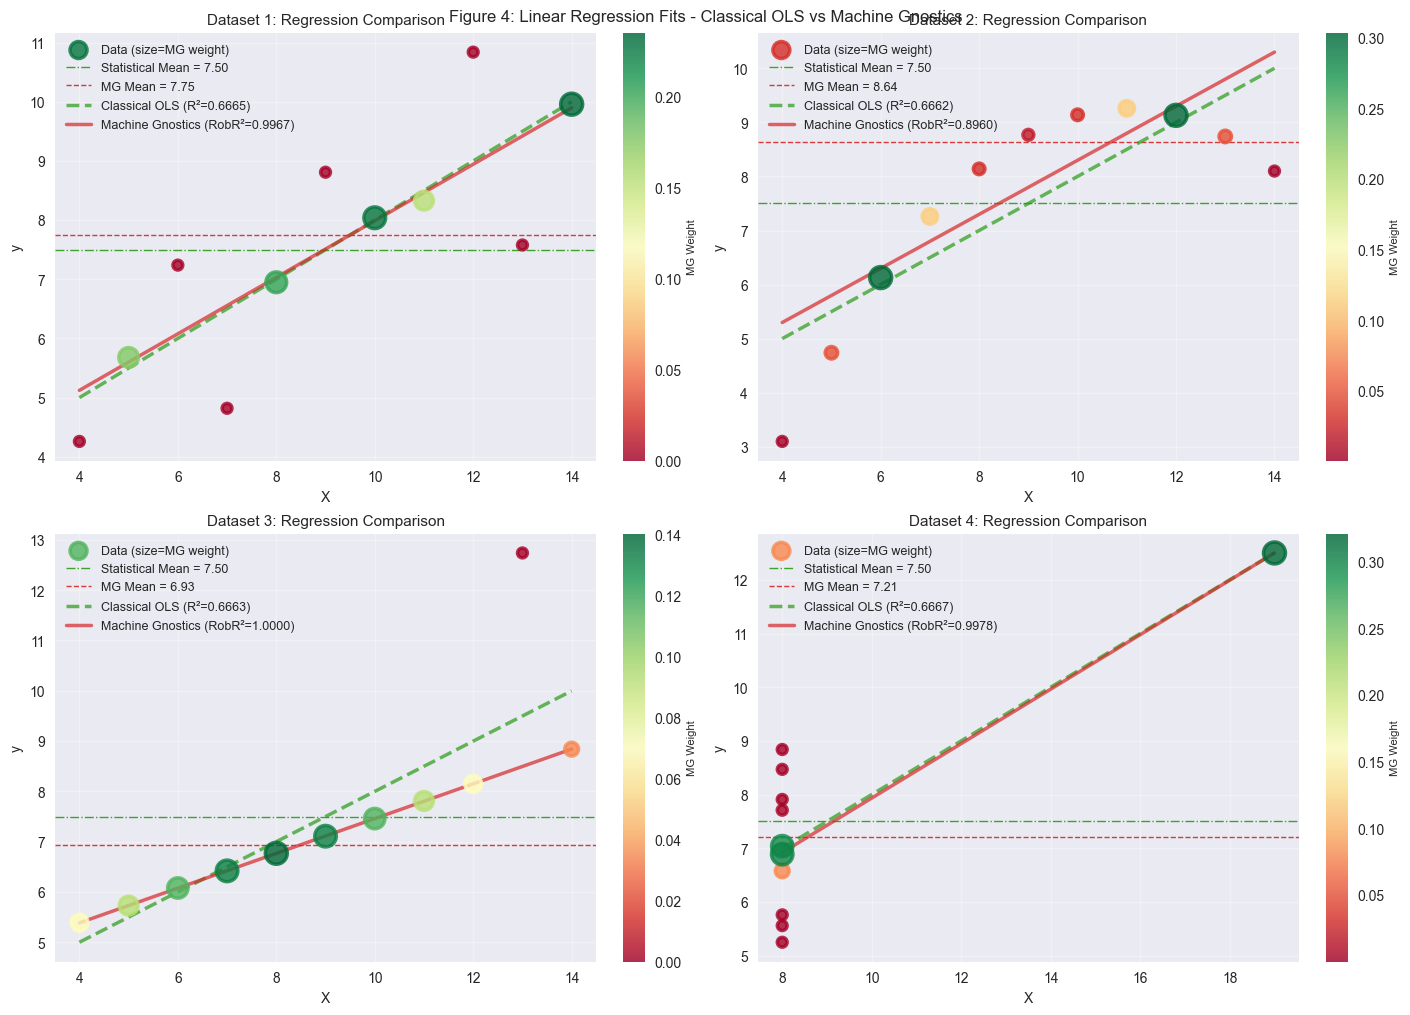

✓ Regression comparison plot created


In [16]:
# 4.1: Regression Fit Comparison - Classical vs Machine Gnostics

fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
axes = axes.ravel()

for i, ds_id in enumerate([1, 2, 3, 4]):
    ax = axes[i]
    
    X = metrics_all[ds_id]["X"]
    y = metrics_all[ds_id]["y"]
    
    # Classical fit
    cls_metrics = metrics_all[ds_id]["classical"]
    y_pred_cls = cls_metrics["y_pred"]
    r2_cls = cls_metrics["r2"]
    
    # MG fit
    mg_metrics = metrics_all[ds_id]["mg"]
    y_pred_mg = mg_metrics["y_pred"]
    r2_mg = mg_metrics["r2"]
    
    # Get weights from MG model for bubble size and color
    model = mg_metrics["model"]
    weights = getattr(model, "weights", None)
    
    if weights is not None:
        weights_array = np.asarray(weights).reshape(-1)
        if weights_array.size == len(X):
            # Normalize weights to bubble sizes [50, 250]
            sizes = 50 + (weights_array - np.min(weights_array)) / (np.max(weights_array) - np.min(weights_array) + 1e-10) * 200
            # Plot with markers, sized by weights, colored by weights
            scatter = ax.scatter(X, y, s=sizes, c=weights_array, marker='o', linewidth=2.5, 
                               cmap="RdYlGn", alpha=0.8, label="Data (size=MG weight)", 
                               vmin=np.min(weights_array), vmax=np.max(weights_array), zorder=3)
            cbar = plt.colorbar(scatter, ax=ax)
            cbar.set_label("MG Weight", fontsize=8)
        else:
            # Fallback if weights size doesn't match
            ax.scatter(X, y, s=100, marker='x', linewidth=2.5, alpha=0.7, 
                      color="#1f77b4", label="Data", zorder=3)
    else:
        # Fallback if no weights available
        ax.scatter(X, y, s=100, marker='x', linewidth=2.5, alpha=0.7, 
                  color="#1f77b4", label="Data", zorder=3)
    
    # Statistical mean of y
    mean_y_stat = np.mean(y)
    ax.axhline(y=mean_y_stat, color="#299b15", linestyle="-.", lw=1, alpha=0.9, 
               label=f"Statistical Mean = {mean_y_stat:.2f}", zorder=1)
    
    # MG mean of y
    mean_y_mg = metrics_all[ds_id]["mg"]["mean_y"]
    ax.axhline(y=mean_y_mg, color="#d62728", linestyle="--", lw=1, alpha=0.9, 
               label=f"MG Mean = {mean_y_mg:.2f}", zorder=1)
    
    # Classical regression line
    X_sorted = np.sort(X)
    idx_cls = np.argsort(X)
    ax.plot(X_sorted, y_pred_cls[idx_cls], "--", lw=2.5, 
            label=f"Classical OLS (R²={r2_cls:.4f})", color="#299b15", alpha=0.7, zorder=2)
    
    # MG regression line
    ax.plot(X_sorted, y_pred_mg[idx_cls], "-", lw=2.5,
            label=f"Machine Gnostics (RobR²={r2_mg:.4f})", color="#d62728", alpha=0.7, zorder=2)
    
    ax.set_xlabel("X", fontsize=10)
    ax.set_ylabel("y", fontsize=10)
    ax.set_title(f"Dataset {ds_id}: Regression Comparison", fontsize=11)
    ax.legend(loc="best", fontsize=9)
    ax.grid(alpha=0.3)

fig.suptitle("Figure 4: Linear Regression Fits - Classical OLS vs Machine Gnostics", y=1.00)
plt.show()

print("✓ Regression comparison plot created")

### Interpretation
Even though classical metrics can look similar across Anscombe datasets, the visual fits and machine-gnostics-based summaries expose structural differences in data behavior.